# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

Acknowledge AI: Generative AI (Google Gemini and ChatCPT) was used as a supplementary aid to support understanding of responsible machine learning concepts and assist with reproducing the R code to Python code. In line with principles of transparency and accountability, all modeling decisions, implementation, and analysis were independently reviewed and completed by me, Easier John.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix

In [ ]:
# Load the dataset
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

print("Rows in dataset:", len(raw_data))

Rows in dataset: 7214


In [ ]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [ ]:
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Select columns
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
    "priors_count", "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

# Filtering
df = df[
    (df['days_b_screening_arrest'].between(-30, 30)) &
    (df['is_recid'] != -1) &
    (df['c_charge_degree'] != "O") &
    (df['score_text'] != "N/A")
]

# Type conversions
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True, errors='coerce')

cols_to_factorize = [col for col in df.columns if col not in numeric_vars and col not in datetime_vars]
for col in cols_to_factorize:
    if df[col].dtype != 'datetime64[ns, UTC]':
        df[col] = df[col].astype('category')

df['crime_factor'] = df['c_charge_degree'].astype('category')

df['age_factor'] = df['age_cat'].astype('category')

df['race_factor'] = df['race'].astype('category')

df['gender_factor'] = df['sex'].astype('category')

df['score_factor'] = pd.Categorical(np.where(df['score_text'] != 'Low', 'HighScore', 'LowScore'))

# Get the number of rows
print(len(df))

6172


In [ ]:
df.head(6)

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore
7,43,F,Other,25 - 45,Low,Male,3,-1.0,4,0,0,2013-08-29 08:55:23+00:00,2013-08-30 08:42:13+00:00,F,25 - 45,Other,Male,LowScore


In [ ]:
def glimpse(df):
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")

    for col in df.columns:
        dtype = df[col].dtype


        if "int" in str(dtype):
            dtype_str = "<int>"
        elif "float" in str(dtype):
            dtype_str = "<dbl>"
        elif "datetime" in str(dtype):
            dtype_str = "<dttm>"
        else:
            dtype_str = "<fct>"

        values = [str(x) for x in df[col].head(12)]
        values_str = ", ".join(values)

        if len(df[col]) > 12:
            values_str += "…"

        print(f"$ {col:<23} {dtype_str:<6} {values_str}")

glimpse(df)

Rows: 6,172
Columns: 18
$ age                     <int>  69, 34, 24, 44, 41, 43, 39, 27, 23, 37, 41, 47…
$ c_charge_degree         <fct>  F, F, F, M, F, F, M, F, M, M, F, F…
$ race                    <fct>  Other, African-American, African-American, Other, Caucasian, Other, Caucasian, Caucasian, African-American, Caucasian, African-American, Caucasian…
$ age_cat                 <fct>  Greater than 45, 25 - 45, Less than 25, 25 - 45, 25 - 45, 25 - 45, 25 - 45, 25 - 45, Less than 25, 25 - 45, 25 - 45, Greater than 45…
$ score_text              <fct>  Low, Low, Low, Low, Medium, Low, Low, Low, Medium, Low, Low, Low…
$ sex                     <fct>  Male, Male, Male, Male, Male, Male, Female, Male, Male, Female, Male, Female…
$ priors_count            <int>  0, 0, 4, 0, 14, 3, 0, 0, 3, 0, 0, 1…
$ days_b_screening_arrest <dbl>  -1.0, -1.0, -1.0, 0.0, -1.0, -1.0, -1.0, -1.0, 0.0, 0.0, -1.0, -20.0…
$ decile_score            <int>  1, 3, 4, 1, 6, 4, 1, 4, 6, 1, 4, 1…
$ is_recid                

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [ ]:
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days

correlation = df["length_of_stay"].corr(df["decile_score"])
print("Correlation:", correlation)

Correlation: 0.20747808478031807


In [ ]:
df["length_of_stay"] = (
    pd.to_datetime(df["c_jail_out"].astype(str).str[:10]) -
    pd.to_datetime(df["c_jail_in"].astype(str).str[:10])
).dt.days

df[["length_of_stay", "decile_score"]].corr().iloc[0, 1]

np.float64(0.20732969161470416)

After filtering we have the following demographic breakdown:

In [ ]:
print(df["age_cat"].value_counts())

age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64


In [ ]:
print(df['race'].value_counts())

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [ ]:
print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [ ]:
print(df['score_text'].value_counts())

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [ ]:
print(pd.crosstab(df['sex'], df['race']))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [ ]:
print(df['sex'].value_counts())

sex
Male      4997
Female    1175
Name: count, dtype: int64


In [ ]:
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [ ]:
num_recid = len(df[df['two_year_recid'] == 1])
print(f"Number of defendants with two-year recidivism: {num_recid}")

Number of defendants with two-year recidivism: 2809


In [ ]:
percentage_recid = (num_recid / len(df)) * 100
print(f"Percentage of defendants with two-year recidivism: {percentage_recid:.5f}%")

Percentage of defendants with two-year recidivism: 45.51199%


Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

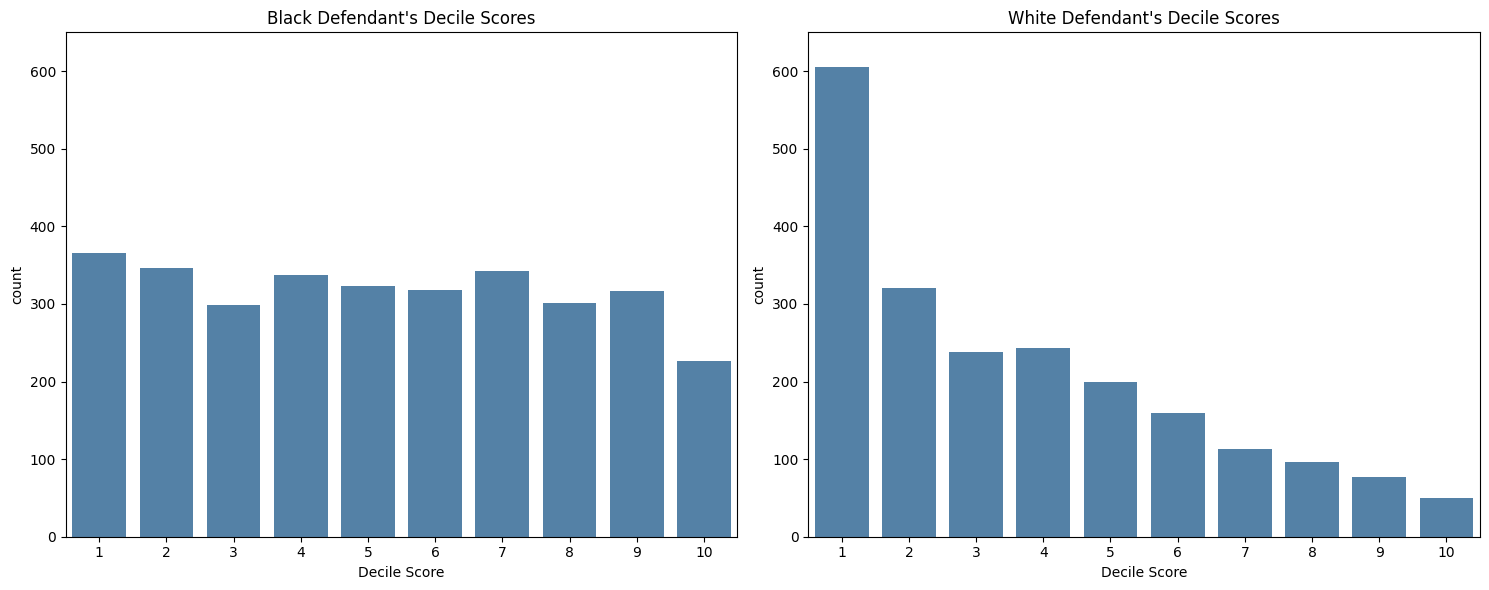

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot for African-American defendants
sns.countplot(x='decile_score', data=df[df['race'] == 'African-American'], ax=axes[0], color='steelblue')
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 650)

# Plot for Caucasian defendants
sns.countplot(x='decile_score', data=df[df['race'] == 'Caucasian'], ax=axes[1], color='steelblue')
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

In [ ]:
print(pd.crosstab(df['decile_score'], df['race']))

race          African-American  Asian  Caucasian  Hispanic  Native American  \
decile_score                                                                  
1                          365     15        605       159                0   
2                          346      4        321        89                2   
3                          298      5        238        73                1   
4                          337      0        243        47                0   
5                          323      1        200        39                0   
6                          318      2        160        27                2   
7                          343      1        113        28                2   
8                          301      2         96        14                0   
9                          317      0         77        17                2   
10                         227      1         50        16                2   

race          Other  
decile_score         
1      

## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [ ]:
df['score_binary'] = (df['score_factor'] == 'HighScore').astype(int)

df['age_factor'] = pd.Categorical(
    df['age_cat'],
    categories=['25 - 45', 'Greater than 45', 'Less than 25']
)

df['gender_factor'] = pd.Categorical(
    df['sex'],
    categories=['Male', 'Female']
)

race_categories_ordered = ['Caucasian', 'African-American', 'Asian', 'Hispanic', 'Native American', 'Other']
df['race_factor'] = pd.Categorical(
    df['race'],
    categories=race_categories_ordered
)

crime_categories = ['F'] + [c for c in df['c_charge_degree'].unique() if c != 'F']
df['crime_factor'] = pd.Categorical(
    df['c_charge_degree'],
    categories=crime_categories
)

formula_str = """
score_binary ~ C(gender_factor)
             + C(age_factor)
             + C(race_factor)
             + priors_count
             + C(crime_factor)
             + two_year_recid
"""

model = smf.logit(formula_str, data=df).fit()


print(model.summary())

pd.reset_option('display.float_format')

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        05:11:44   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -1.5255      0.079    

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [ ]:
import numpy as np

control = np.exp(-1.52554) / (1 + np.exp(-1.52554))
result = np.exp(0.47721) / (1 - control + (control * np.exp(0.47721)))
print(f"result: {result:.7g}")

result: 1.452841


Women are 19.4% more likely than men to get a higher score.

In [ ]:
import numpy as np

control = np.exp(-1.52554) / (1 + np.exp(-1.52554))
result = np.exp(0.22127) / (1 - control + (control * np.exp(0.22127)))
print(f"{result:.7g}")

1.194798


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [ ]:
import numpy as np

control = np.exp(-1.52554) / (1 + np.exp(-1.52554))
result = np.exp(1.30839) / (1 - control + (control * np.exp(1.30839)))
print(f"{result:.7g}")

2.49612


In [ ]:
import numpy as np

# Calculate predicted probabilities using the fitted model
df['pred_prob'] = model.predict(df)

# Classify predictions based on a 0.5 threshold
df['pred_class_numeric'] = np.where(df['pred_prob'] >= 0.5, 1, 0)

# Convert the numeric classification to a categorical variable with specified labels
df['pred_class'] = pd.Categorical(
    df['pred_class_numeric'],
    categories=[0, 1],
    ordered=False
).rename_categories(['No Recid', 'Recid'])

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

print("\n── Overall Confusion Matrix ──────────────────────────────────────────")

actual_values = df['two_year_recid'].astype(int)
predicted_values = df['pred_class_numeric'].astype(int)

# Generate the confusion matrix. sklearn's confusion_matrix returns [[TN, FP], [FN, TP]]
# for binary classification where 0 is negative and 1 is positive.
cm_sklearn = confusion_matrix(actual_values, predicted_values, labels=[0, 1])

# Extract TN, FP, FN, TP
TN = cm_sklearn[0, 0]
FP = cm_sklearn[0, 1]
FN = cm_sklearn[1, 0]
TP = cm_sklearn[1, 1]

#                 Actual
# Predicted    0          1
#   No Recid   TN         FN
#   Recid      FP         TP
overall_cm_py = pd.DataFrame({
    '0': [TN, FP], # Actual 0
    '1': [FN, TP]  # Actual 1
}, index=['No Recid', 'Recid'])
overall_cm_py.columns.name = 'Actual'
overall_cm_py.index.name = 'Predicted'
print(overall_cm_py)

# Calculate overall metrics
n = TP + TN + FP + FN

accuracy = (TP + TN) / n
precision = TP / (TP + FP)
recall = TP / (TP + FN)
fpr = FP / (FP + TN) # False Positive Rate
fnr = FN / (FN + TP) # False Negative Rate

print(f"\nAccuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [ ]:
import pandas as pd
import numpy as np

print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────")

# Ensure actual and predicted are numeric for calculations
# 'two_year_recid' is categorical with '0' and '1' as categories, so astype(int) works.
actual = df['two_year_recid'].astype(int)
pred = df['pred_class_numeric'].astype(int)

def calculate_race_metrics(group_df):
    n = len(group_df)
    TP = ((group_df['pred'] == 1) & (group_df['actual'] == 1)).sum()
    TN = ((group_df['pred'] == 0) & (group_df['actual'] == 0)).sum()
    FP = ((group_df['pred'] == 1) & (group_df['actual'] == 0)).sum()
    FN = ((group_df['pred'] == 0) & (group_df['actual'] == 1)).sum()

    # Calculate metrics, handling potential division by zero with np.nan
    accuracy = (TP + TN) / n if n > 0 else np.nan
    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    fpr = FP / (FP + TN) if (FP + TN) > 0 else np.nan
    fnr = FN / (FN + TP) if (FN + TP) > 0 else np.nan

    return pd.Series({
        'n': n,
        'TP': TP,
        'TN': TN,
        'FP': FP,
        'FN': FN,
        'Accuracy': round(accuracy, 3),
        'Precision': round(precision, 3),
        'Recall': round(recall, 3),
        'FPR': round(fpr, 3),
        'FNR': round(fnr, 3)
    })

# Create a temporary DataFrame with 'actual' and 'pred' for grouping
temp_df = df.copy()
temp_df['actual'] = actual
temp_df['pred'] = pred

race_metrics = temp_df.groupby('race').apply(calculate_race_metrics).reset_index()

# Arrange by 'n' in descending order
race_metrics = race_metrics.sort_values(by='n', ascending=False)

print(race_metrics)



── Confusion Matrix by Race ──────────────────────────────────────────
               race       n      TP      TN     FP     FN  Accuracy  \
0  African-American  3175.0  1373.0   959.0  555.0  288.0     0.734   
2         Caucasian  2103.0   381.0  1148.0  133.0  441.0     0.727   
3          Hispanic   509.0    81.0   306.0   14.0  108.0     0.760   
5             Other   343.0    22.0   216.0    3.0  102.0     0.694   
1             Asian    31.0     2.0    22.0    1.0    6.0     0.774   
4   Native American    11.0     5.0     2.0    4.0    0.0     0.636   

   Precision  Recall    FPR    FNR  
0      0.712   0.827  0.367  0.173  
2      0.741   0.464  0.104  0.536  
3      0.853   0.429  0.044  0.571  
5      0.880   0.177  0.014  0.823  
1      0.667   0.250  0.043  0.750  
4      0.556   1.000  0.667  0.000  


/tmp/ipykernel_5638/3021892967.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  race_metrics = temp_df.groupby('race').apply(calculate_race_metrics).reset_index()
/tmp/ipykernel_5638/3021892967.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  race_metrics = temp_df.groupby('race').apply(calculate_race_metrics).reset_index()


In [ ]:
print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────")

# Select relevant columns
disparity = race_metrics[['race', 'n', 'FPR', 'FNR']].copy()

# Get FPR and FNR for Caucasian race (reference)
caucasian_fpr = disparity.loc[disparity['race'] == 'Caucasian', 'FPR'].iloc[0]
caucasian_fnr = disparity.loc[disparity['race'] == 'Caucasian', 'FNR'].iloc[0]

# Calculate delta_FPR and delta_FNR
disparity['delta_FPR'] = round(disparity['FPR'] - caucasian_fpr, 3)
disparity['delta_FNR'] = round(disparity['FNR'] - caucasian_fnr, 3)

print(disparity)



── FPR and FNR Disparity by Race ─────────────────────────────────────
               race       n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175.0  0.367  0.173      0.263     -0.363
2         Caucasian  2103.0  0.104  0.536      0.000      0.000
3          Hispanic   509.0  0.044  0.571     -0.060      0.035
5             Other   343.0  0.014  0.823     -0.090      0.287
1             Asian    31.0  0.043  0.750     -0.061      0.214
4   Native American    11.0  0.667  0.000      0.563     -0.536
